# 01 - Data Exploration
## Fake News Detection - EDA and Visualization

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

In [2]:
# Load dataset
df = pd.read_csv('../data/WELFake_Dataset.csv')
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (72134, 4)


,Unnamed: 0,title,text,label
0,0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,1,NaN,Did they post their votes for Hillary already?,1
2,2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1
3,3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0
4,4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1


In [3]:
# Dataset information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 72134 entries, 0 to 72133
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Unnamed: 0  72134 non-null  int64
 1   title       71576 non-null  str  
 2   text        72095 non-null  str  
 3   label       72134 non-null  int64
dtypes: int64(2), str(2)
memory usage: 2.2 MB


In [4]:
# Check for missing values
df.isnull().sum()

Unnamed: 0      0
title         558
text           39
label           0
dtype: int64

label
1    37106
0    35028
Name: count, dtype: int64

Percentage: label
1    51.440375
0    48.559625
Name: proportion, dtype: float64


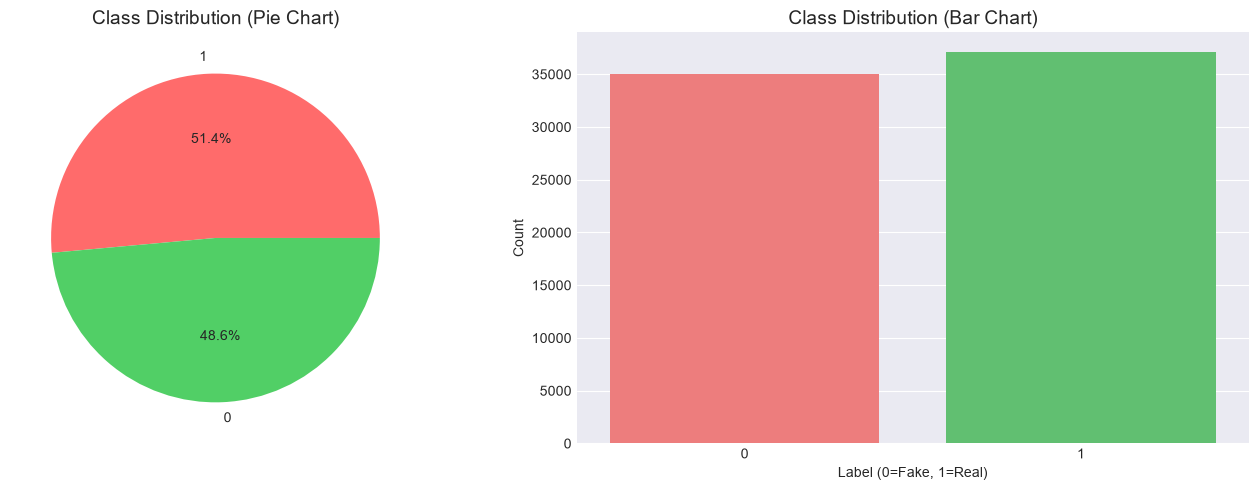

In [5]:
# Class distribution
print(df['label'].value_counts())
print(f"\nPercentage: {df['label'].value_counts(normalize=True) * 100}")

# Visualize class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
df['label'].value_counts().plot.pie(ax=axes[0], autopct='%1.1f%%', colors=['#ff6b6b', '#51cf66'])
axes[0].set_title('Class Distribution (Pie Chart)', fontsize=14)
axes[0].set_ylabel('')

# Bar chart
sns.countplot(data=df, x='label', ax=axes[1], palette=['#ff6b6b', '#51cf66'])
axes[1].set_title('Class Distribution (Bar Chart)', fontsize=14)
axes[1].set_xlabel('Label (0=Fake, 1=Real)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

In [6]:
# Text length analysis
df['text_length'] = df['text'].str.len()
df['word_count'] = df['text'].str.split().str.len()

# Statistics
print("Text Length Statistics:")
print(df['text_length'].describe())
print("\nWord Count Statistics:")
print(df['word_count'].describe())

Text Length Statistics:
count     72095.000000
mean       3270.155878
std        3733.112756
min           1.000000
25%        1379.000000
50%        2425.000000
75%        4060.000000
max      142961.000000
Name: text_length, dtype: float64

Word Count Statistics:
count    72095.000000
mean       540.843346
std        625.442464
min          0.000000
25%        227.000000
50%        399.000000
75%        667.000000
max      24234.000000
Name: word_count, dtype: float64


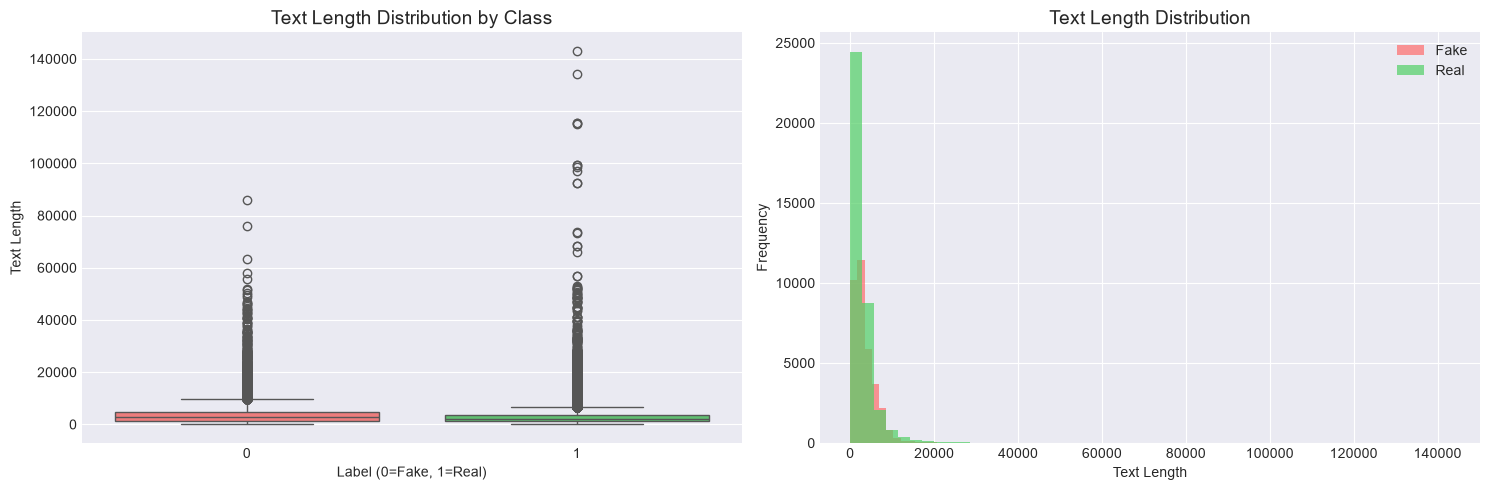

In [7]:
# Text length by class
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Box plot
sns.boxplot(data=df, x='label', y='text_length', ax=axes[0], palette=['#ff6b6b', '#51cf66'])
axes[0].set_title('Text Length Distribution by Class', fontsize=14)
axes[0].set_xlabel('Label (0=Fake, 1=Real)')
axes[0].set_ylabel('Text Length')

# Histogram
df[df['label']==0]['text_length'].hist(alpha=0.7, label='Fake', color='#ff6b6b', bins=50)
df[df['label']==1]['text_length'].hist(alpha=0.7, label='Real', color='#51cf66', bins=50)
axes[1].set_title('Text Length Distribution', fontsize=14)
axes[1].set_xlabel('Text Length')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.show()

In [8]:
# Sample texts from each class
print("=" * 50)
print("SAMPLE FAKE NEWS:")
print("=" * 50)
for i, text in enumerate(df[df['label']==0]['text'].head(3)):
    print(f"\n{i+1}. {text[:300]}...")

print("\n" + "=" * 50)
print("SAMPLE REAL NEWS:")
print("=" * 50)
for i, text in enumerate(df[df['label']==1]['text'].head(3)):
    print(f"\n{i+1}. {text[:300]}...")

SAMPLE FAKE NEWS:

1. A dozen politically active pastors came here for a private dinner Friday night to hear a conversion story unique in the context of presidential politics: how Louisiana Gov. Bobby Jindal traveled from Hinduism to Protestant Christianity and, ultimately, became what he calls an “evangelical Catholic.”...

2. BRUSSELS (Reuters) - British Prime Minister Theresa May s offer of  settled status  for EU residents is flawed and will leave them with fewer rights after Brexit, the European Parliament s Brexit coordinator said on Tuesday. A family of five could face a bill of 360 pounds to acquire the new status,...

3. WASHINGTON (Reuters) - Charles Schumer, the top Democrat in the U.S. Senate, called on President Donald Trump on Sunday to name a single official to oversee and coordinate relief efforts in hurricane-ravaged Puerto Rico. Schumer, along with Representatives Nydia Velàzquez and Jose Serrano, said a “C...

SAMPLE REAL NEWS:

1. No comment is expected from Barack 

In [9]:
# Dataset summary
print("=" * 40)
print("DATASET SUMMARY")
print("=" * 40)
print(f"Total samples: {len(df)}")
print(f"Features: {df.columns.tolist()}")
print(f"Target: label (0=Fake, 1=Real)")
print(f"Class balance: {df['label'].value_counts().to_dict()}")
print(f"Average text length: {df['text_length'].mean():.0f} characters")
print(f"Average word count: {df['word_count'].mean():.0f} words")

DATASET SUMMARY
Total samples: 72134
Features: ['Unnamed: 0', 'title', 'text', 'label', 'text_length', 'word_count']
Target: label (0=Fake, 1=Real)
Class balance: {1: 37106, 0: 35028}
Average text length: 3270 characters
Average word count: 541 words
